In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root added to path:", PROJECT_ROOT)


Project root added to path: d:\projects\Criminal-Activity-Video-Surveillance-using-Deep-Learning


In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from imutils import paths

import imageio
import cv2
import os

import utils.notebook_utils as utils
from IPython import display
import collections
import time
import numpy as np

import multiprocessing
num_cores = multiprocessing.cpu_count()

from openvino.runtime import Core

In [3]:
decoder = load_model('../Models/classifier_lstm_e19.h5', compile=False)
#decoder = load_model('../Models/classifier_lstm_e17_for_resnet_encoder.h5', compile=False)

In [4]:
decoder.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 32, 2048)]        0         
                                                                 
 lstm_2 (LSTM)               (None, 32, 256)           2360320   
                                                                 
 lstm_3 (LSTM)               (None, 128)               197120    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 32)                4128      
                                                                 
 dense_3 (Dense)             (None, 10)                330       
                                                                 
Total params: 2,561,898
Trainable params: 2,561,898
Non-tra

In [5]:
#Define hyperparameters

IMG_SIZE = (299, 224)
BATCH_SIZE = 30
EPOCHS = 100

MAX_SEQ_LENGTH = 32
NUM_FEATURES = 2048

In [6]:
# Load the network
ie = Core()
model_ir = ie.read_model(model="../Models/inceptionv3_model_ir/saved_model.xml")
compiled_model_ir = ie.compile_model(model=model_ir, device_name="CPU")

# Get output layer
output_layer_ir = compiled_model_ir.output(0)

In [7]:
#encoder = load_model("model/my_trained_models/best_model/feature_extractor_inceptionv3.h5")#, compile=False)
#encoder = load_model("model/my_trained_models/models_for_resnet_encoder/encoder_resnet50.h5")#, compile=False)

In [8]:
#encoder.summary()

In [9]:
# Get input size - Encoder.
# height_en, width_en = list(input_key_en.shape)[2:]
try:
    height_en, width_en = list(encoder.inputs[0].shape)[1:3]
except NameError:
    # encoder is not defined, use compiled_model_ir instead
    height_en, width_en = list(compiled_model_ir.inputs[0].shape)[1:3]

# Get input size - Decoder.
# frames2decode = list(input_key_de.shape)[0:][1]
# The decoder has only one input (encoder outputs), get the sequence length from it
frames2decode = list(decoder.inputs[0].shape)[1]

In [10]:
# label_processor.get_vocabulary()
class_vocab = ['Abuse', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'Normal', 'RoadAccidents', 'Robbery', 'Shooting']

In [11]:
def crop_center_square(frame):
    y, x = frame.shape[0:2]
    min_dim = min(y, x)
    start_x = (x // 2) - (min_dim // 2)
    start_y = (y // 2) - (min_dim // 2)
    return frame[start_y : start_y + min_dim, start_x : start_x + min_dim]

In [12]:
def center_crop(frame: np.ndarray) -> np.ndarray:
    """
    Center crop squared the original frame to standardize the input image to the encoder model

    :param frame: input frame
    :returns: center-crop-squared frame
    """
    img_h, img_w, _ = frame.shape
    min_dim = min(img_h, img_w)
    start_x = int((img_w - min_dim) / 2.0)
    start_y = int((img_h - min_dim) / 2.0)
    roi = [start_y, (start_y + min_dim), start_x, (start_x + min_dim)]
    return frame[start_y : (start_y + min_dim), start_x : (start_x + min_dim), ...], roi

def rec_frame_display(frame: np.ndarray, roi) -> np.ndarray:
    """
    Draw a rec frame over actual frame

    :param frame: input frame
    :param roi: Region of interest, image section processed by the Encoder
    :returns: frame with drawed shape

    """

    cv2.line(frame, (roi[2] + 3, roi[0] + 3), (roi[2] + 3, roi[0] + 100), (0, 200, 0), 2)
    cv2.line(frame, (roi[2] + 3, roi[0] + 3), (roi[2] + 100, roi[0] + 3), (0, 200, 0), 2)
    cv2.line(frame, (roi[3] - 3, roi[1] - 3), (roi[3] - 3, roi[1] - 100), (0, 200, 0), 2)
    cv2.line(frame, (roi[3] - 3, roi[1] - 3), (roi[3] - 100, roi[1] - 3), (0, 200, 0), 2)
    cv2.line(frame, (roi[3] - 3, roi[0] + 3), (roi[3] - 3, roi[0] + 100), (0, 200, 0), 2)
    cv2.line(frame, (roi[3] - 3, roi[0] + 3), (roi[3] - 100, roi[0] + 3), (0, 200, 0), 2)
    cv2.line(frame, (roi[2] + 3, roi[1] - 3), (roi[2] + 3, roi[1] - 100), (0, 200, 0), 2)
    cv2.line(frame, (roi[2] + 3, roi[1] - 3), (roi[2] + 100, roi[1] - 3), (0, 200, 0), 2)
    # Write ROI over actual frame
    FONT_STYLE = cv2.FONT_HERSHEY_SIMPLEX
    org = (roi[2] + 3, roi[1] - 3)
    org2 = (roi[2] + 2, roi[1] - 2)
    FONT_SIZE = 0.5
    FONT_COLOR = (0, 200, 0)
    FONT_COLOR2 = (0, 0, 0)
    cv2.putText(frame, "ROI", org2, FONT_STYLE, FONT_SIZE, FONT_COLOR2)
    cv2.putText(frame, "ROI", org, FONT_STYLE, FONT_SIZE, FONT_COLOR)
    return frame

In [13]:
def display_text_fnc_modified(frame, display_text, index):
    # Configuration for displaying images with text.
    FONT_COLOR = (255, 255, 255)
    FONT_COLOR2 = (0, 0, 0)
    FONT_STYLE = cv2.FONT_HERSHEY_DUPLEX
    FONT_SIZE = 0.7
    TEXT_VERTICAL_INTERVAL = 25
    TEXT_LEFT_MARGIN = 15
    
    text_loc = (TEXT_LEFT_MARGIN, TEXT_VERTICAL_INTERVAL * (index + 1))
    text_loc2 = (TEXT_LEFT_MARGIN + 1, TEXT_VERTICAL_INTERVAL * (index + 1) + 1)
    
    # _ = cv2.putText(frame, 'OpenCV', text_loc, cv2.FONT_HERSHEY_DUPLEX, 1,         (255, 0, 0))
    #   # cv2.putText(frame, display_, text_loc, FONT_STYLE,              FONT_SIZE, FONT_COLOR)
    # _ = cv2.putText(frame, display_text, text_loc2, FONT_STYLE, FONT_SIZE, FONT_COLOR2)
    frame2 = frame.copy()
    _ = cv2.putText(frame2, display_text, text_loc, FONT_STYLE, FONT_SIZE, FONT_COLOR)
    # plt.imshow(_)
    return frame2

In [14]:
def display_text_fnc(frame, display_text, index):
    """
    Include a text on the analyzed frame

    :param frame: input frame
    :param display_text: text to add on the frame
    :param index: index line dor adding text

    """
    # Configuration for displaying images with text.
    FONT_COLOR = (255, 255, 255)
    FONT_COLOR2 = (0, 0, 0)
    FONT_STYLE = cv2.FONT_HERSHEY_DUPLEX
    FONT_SIZE = 0.5
    TEXT_VERTICAL_INTERVAL = 25
    TEXT_LEFT_MARGIN = 15
    
    # # ROI over actual frame
    # (processed, roi) = center_crop(frame)
    # # Draw a ROI over actual frame.
    # frame = rec_frame_display(frame, roi)
    
    # Put a text over actual frame.
    text_loc = (TEXT_LEFT_MARGIN, TEXT_VERTICAL_INTERVAL * (index + 1))
    text_loc2 = (TEXT_LEFT_MARGIN + 1, TEXT_VERTICAL_INTERVAL * (index + 1) + 1)
    frame2 = frame.copy()
    _ = cv2.putText(frame2, display_text, text_loc2, FONT_STYLE, FONT_SIZE, FONT_COLOR2)
    _ = cv2.putText(frame2, display_text, text_loc, FONT_STYLE, FONT_SIZE, FONT_COLOR)
    return frame2

In [15]:
frames_idx = []

In [16]:
def run_action_recognition(
    source: str = '0',
    flip: bool = True,
    skip_first_frames: int = 0
):
    """
    Run action recognition on video source using encoder-decoder architecture.
    
    Encoder (InceptionV3): Extracts spatial features from individual frames
    Decoder (LSTM): Temporal classification over sequence of frame features
    
    :param source: Path to video file or '0' for webcam
    :param flip: Whether to flip the video horizontally
    :param skip_first_frames: Number of frames to skip at start
    """
    size = height_en  # Encoder input size
    sample_duration = frames2decode  # Decoder input size
    fps = 30
    player = None
    
    final_inf_counter = 0
    final_infer_time = time.time()
    final_infer_duration = 0
    
    global frames_idx
    frame_counter = None
    
    try:
        # Create a video player
        player = utils.VideoPlayer(source, flip=flip, fps=fps, skip_first_frames=skip_first_frames)
        player.start()
        
        processing_times = collections.deque()
        processing_time = 0
        encoder_output = []
        decoded_labels = ['N/A', 'N/A', 'N/A']
        decoded_top_probs = [0.0, 0.0, 0.0]
        counter = 0
        
        # Text templates for display
        text_inference_template = "Infer Time:{Time:.1f}ms"
        text_template = "{label},{conf:.2f}%"
        
        print("Starting inference... Press Ctrl+C to stop.")
        
        while True:
            counter += 1
            frame, frame_counter = player.next()
            
            if frame is None:
                print("Source ended")
                break
            
            # Preprocess frame
            preprocessed = cv2.resize(frame, IMG_SIZE)
            preprocessed = preprocessed[:, :, [2, 1, 0]]  # BGR -> RGB
            
            # Process every other frame through encoder
            if counter % 2 == 0:
                frames_idx.append((counter, frame_counter, 'Yes'))
                
                start_time = time.time()
                
                # Encoder inference
                try:
                    encoder_output.append(
                        compiled_model_ir([preprocessed[None, ...]])[output_layer_ir][0]
                    )
                except Exception as e:
                    print(f"Error in encoder inference: {e}")
                    continue
                
                # Decoder inference when sequence is complete
                if len(encoder_output) == sample_duration:
                    try:
                        encoder_output_array = np.array(encoder_output)[None, ...]
                        probabilities = decoder.predict(encoder_output_array)[0]
                        
                        # Get top 3 predictions
                        for idx, i in enumerate(np.argsort(probabilities)[::-1][:3]):
                            decoded_labels[idx] = class_vocab[i]
                            decoded_top_probs[idx] = probabilities[i]
                        
                        encoder_output = []
                        final_inf_counter += 1
                        final_infer_duration = time.time() - final_infer_time
                        final_infer_time = time.time()
                    except Exception as e:
                        print(f"Error in decoder inference: {e}")
                        encoder_output = []
                
                stop_time = time.time()
                processing_times.append(stop_time - start_time)
                
                # Keep only last 200 processing times for averaging
                if len(processing_times) > 200:
                    processing_times.popleft()
                
                if processing_times:
                    processing_time = np.mean(processing_times) * 1000
            else:
                frames_idx.append((counter, frame_counter, 'No'))
            
            # Prepare output frame
            display_frame = cv2.resize(frame, (620, 350))
            
            # Add prediction labels
            for i in range(3):
                display_text = text_template.format(
                    label=decoded_labels[i],
                    conf=decoded_top_probs[i] * 100,
                )
                display_frame = display_text_fnc(display_frame, display_text, i)
            
            # Add inference time
            display_text = text_inference_template.format(Time=processing_time)
            display_frame = display_text_fnc(display_frame, display_text, 3)
            
            # Add inference counter
            display_frame = display_text_fnc(
                display_frame, 
                f"Infer Count: {final_inf_counter}", 
                4
            )
            
            # Display frame in notebook
            _, encoded_img = cv2.imencode(
                ".jpg", 
                display_frame, 
                params=[cv2.IMWRITE_JPEG_QUALITY, 90]
            )
            i = display.Image(data=encoded_img)
            display.clear_output(wait=True)
            display.display(i)
    
    except KeyboardInterrupt:
        print("\nInference stopped by user")
    except RuntimeError as e:
        print(f"Runtime error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")
    finally:
        if player is not None:
            player.stop()
            print("Video player stopped")

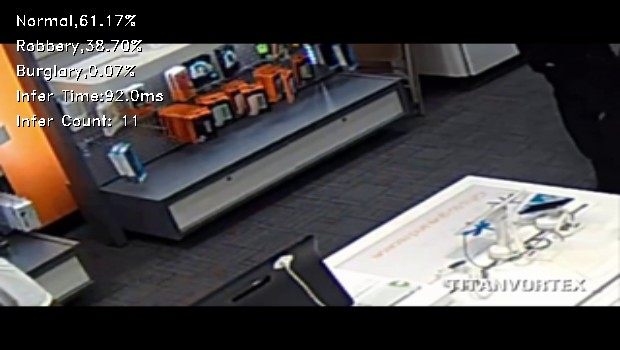

Source ended
Video player stopped


In [ ]:
try:
	# Note: Update the video source path to a valid video file in your system
	run_action_recognition(source="..\ATM robbery\Police_Thieves_used_stolen_SUV_to_pull_ATM_from_convenience_store_720P.mp4", flip=False, skip_first_frames=0)  # Using webcam as default
	# Alternative: run_action_recognition(source="../Data/path_to_your_video.mp4", flip=False, skip_first_frames=34)
except Exception as e:
    print(f"Error: {e}")
    print("Good Bye")

In [18]:
#import tensorflow as tf
#emb_model = tf.keras.models.load_model('model/my_trained_models/best_model/feature_extractor_inceptionv3.h5')
#tf.saved_model.save(emb_model, 'inceptionv3_model')